# Field Line Directional Derivatives Guide - 9 Key Formulas

This notebook demonstrates the usage, performance, and accuracy of the vectorized directional derivative implementation that focuses on the 9 key formulas for magnetic field line geometry in the geopack-vectorize library.

## Table of Contents
1. [Introduction](#introduction)
2. [Mathematical Background](#mathematical-background)
3. [Basic Usage](#basic-usage)
4. [Performance Benchmarks](#performance-benchmarks)
5. [Accuracy Validation](#accuracy-validation)
6. [Practical Applications](#practical-applications)
7. [Limitations and Considerations](#limitations)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Import Geopack functions
from geopack import recalc
from geopack.models import t96
from geopack.vectorized import (
    t96_vectorized,
    field_line_curvature_vectorized,
    field_line_torsion_vectorized,
    field_line_frenet_frame_vectorized,
    field_line_directional_derivatives_vectorized,
    verify_antisymmetry_relations
)

# Set up model parameters
ut = datetime(2023, 3, 15, 12, 0, 0).timestamp()
ps = recalc(ut)

# T96 model parameters
Pdyn = 2.0    # Solar wind dynamic pressure (nPa)
Dst = -20     # Dst index (nT)
ByIMF = 0.0   # IMF By (nT)
BzIMF = -5.0  # IMF Bz (nT)
parmod = [Pdyn, Dst, ByIMF, BzIMF, 0, 0, 0, 0, 0, 0]

print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")
print(f"Model parameters: Pdyn={Pdyn} nPa, Dst={Dst} nT, By={ByIMF} nT, Bz={BzIMF} nT")

def get_max_antisymmetry_error(derivatives):
    """Get maximum antisymmetry error, handling both scalar and array inputs."""
    errors = verify_antisymmetry_relations(derivatives)
    max_errors = []
    for key, error in errors.items():
        if hasattr(error, 'shape'):  # It's an array
            max_errors.append(np.max(np.abs(error)))
        else:  # It's a scalar
            max_errors.append(abs(error))
    return max(max_errors)


Dipole tilt angle: -10.30 degrees
Model parameters: Pdyn=2.0 nPa, Dst=-20 nT, By=0.0 nT, Bz=-5.0 nT


<a id='introduction'></a>
## 1. Introduction

The `field_line_directional_derivatives_vectorized` function computes the 9 key directional derivative formulas that describe how the Frenet-Serret frame vectors (tangent **T**, normal **n**, and binormal **b**) change along magnetic field lines.

### The 9 Key Formulas:
1. **(∂T/∂T)·n = κ** (curvature)
2. **(∂T/∂T)·b = 0**
3. **(∂n/∂T)·b = τ** (torsion)
4. **(∂T/∂n)·n**
5. **(∂T/∂n)·b**
6. **(∂n/∂n)·b**
7. **(∂n/∂b)·b**
8. **(∂n/∂b)·T**
9. **(∂b/∂b)·T**

These formulas satisfy antisymmetry relations: If (∂A/∂B)·C = value, then (∂C/∂B)·A = -value.

<a id='mathematical-background'></a>
## 2. Mathematical Background

### Frenet-Serret Frame
For a space curve (magnetic field line), the Frenet-Serret frame consists of orthonormal unit vectors:
- **T**: Unit tangent vector (along the field line), |T| = 1
- **n**: Unit principal normal vector (points toward center of curvature), |n| = 1
- **b**: Unit binormal vector (**b** = **T** × **n**), |b| = 1

These vectors satisfy:
- T·T = n·n = b·b = 1 (unit vectors)
- T·n = T·b = n·b = 0 (orthogonal)

### Frenet-Serret Formulas
The derivatives with respect to arc length s are:
- d**T**/ds = κ**n**
- d**n**/ds = -κ**T** + τ**b**
- d**b**/ds = -τ**n**

where κ is the curvature and τ is the torsion.

### Key Properties for Unit Vectors
Since T, n, and b are unit vectors:
1. **Self-perpendicularity**: The derivative of a unit vector is perpendicular to itself
   - (∂T/∂s)·T = 0 for any direction s
   - (∂n/∂s)·n = 0 for any direction s
   - (∂b/∂s)·b = 0 for any direction s
2. **Antisymmetry**: If (∂A/∂B)·C = value, then (∂C/∂B)·A = -value

The 9 formulas capture all non-zero components while respecting these constraints.

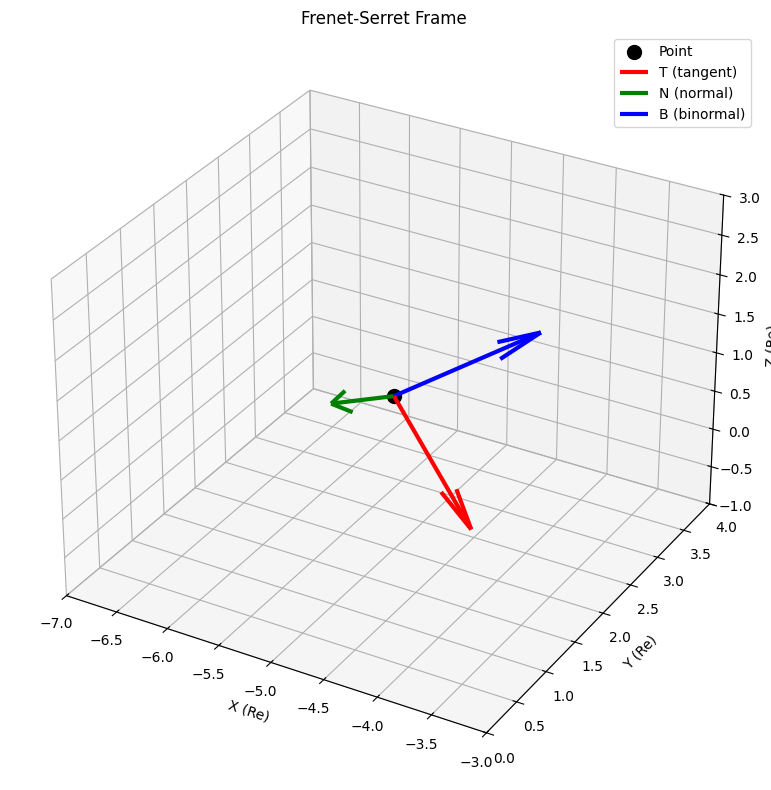

Orthonormality check:
T·T = 1.0000000000 (should be 1)
N·N = 1.0000000000 (should be 1)
B·B = 0.9999999998 (should be 1)
T·N = -0.0000157840 (should be 0)
T·B = -0.0000000000 (should be 0)
N·B = -0.0000000000 (should be 0)

Curvature at this point: 0.268441 1/Re


In [30]:
# Visualize the Frenet-Serret frame at a point
x0, y0, z0 = -5.0, 2.0, 1.0

# Get Frenet frame
tx, ty, tz, nx, ny, nz, bx, by, bz, curv = field_line_frenet_frame_vectorized(
    t96_vectorized, parmod, ps, x0, y0, z0
)

# Create 3D visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the point
ax.scatter([x0], [y0], [z0], c='black', s=100, label='Point')

# Plot frame vectors
scale = 1.5
ax.quiver(x0, y0, z0, tx*scale, ty*scale, tz*scale, 
          color='red', arrow_length_ratio=0.3, linewidth=3, label='T (tangent)')
ax.quiver(x0, y0, z0, nx*scale, ny*scale, nz*scale, 
          color='green', arrow_length_ratio=0.3, linewidth=3, label='N (normal)')
ax.quiver(x0, y0, z0, bx*scale, by*scale, bz*scale, 
          color='blue', arrow_length_ratio=0.3, linewidth=3, label='B (binormal)')

ax.set_xlabel('X (Re)')
ax.set_ylabel('Y (Re)')
ax.set_zlabel('Z (Re)')
ax.set_title('Frenet-Serret Frame')
ax.legend()

# Set equal aspect ratio
max_range = 2
ax.set_xlim([x0-max_range, x0+max_range])
ax.set_ylim([y0-max_range, y0+max_range])
ax.set_zlim([z0-max_range, z0+max_range])

plt.tight_layout()
plt.show()

# Verify orthonormality
print("Orthonormality check:")
print(f"T·T = {tx**2 + ty**2 + tz**2:.10f} (should be 1)")
print(f"N·N = {nx**2 + ny**2 + nz**2:.10f} (should be 1)")
print(f"B·B = {bx**2 + by**2 + bz**2:.10f} (should be 1)")
print(f"T·N = {tx*nx + ty*ny + tz*nz:.10f} (should be 0)")
print(f"T·B = {tx*bx + ty*by + tz*bz:.10f} (should be 0)")
print(f"N·B = {nx*bx + ny*by + nz*bz:.10f} (should be 0)")
print(f"\nCurvature at this point: {curv:.6f} 1/Re")

<a id='basic-usage'></a>
## 3. Basic Usage

Let's demonstrate how to use the directional derivative functions.

In [31]:
# Single point calculation
x, y, z = -5.0, 0.0, 0.0

# Calculate all 9 directional derivatives
derivatives = field_line_directional_derivatives_vectorized(
    t96_vectorized, parmod, ps, x, y, z
)

print("Directional Derivatives at ({:.1f}, {:.1f}, {:.1f}) Re:".format(x, y, z))
print("=" * 60)

print("\nThe 9 Key Formulas:")
print("-" * 40)
print("\n1. Tangential derivatives (Frenet-Serret):")
print(f"   (∂T/∂T)·n = {derivatives['dT_dT_n']:8.5f}  (curvature κ)")
print(f"   (∂T/∂T)·b = {derivatives['dT_dT_b']:8.5f}  (should be 0)")
print(f"   (∂n/∂T)·b = {derivatives['dn_dT_b']:8.5f}  (torsion τ)")

print("\n2. Normal derivatives:")
print(f"   (∂T/∂n)·n = {derivatives['dT_dn_n']:8.5f}")
print(f"   (∂T/∂n)·b = {derivatives['dT_dn_b']:8.5f}")
print(f"   (∂n/∂n)·b = {derivatives['dn_dn_b']:8.5f}")

print("\n3. Binormal derivatives:")
print(f"   (∂n/∂b)·b = {derivatives['dn_db_b']:8.5f}")
print(f"   (∂n/∂b)·T = {derivatives['dn_db_T']:8.5f}")
print(f"   (∂b/∂b)·T = {derivatives['db_db_T']:8.5f}")

# Compare with standard curvature and torsion functions
curvature_std = field_line_curvature_vectorized(t96_vectorized, parmod, ps, x, y, z)
torsion_std = field_line_torsion_vectorized(t96_vectorized, parmod, ps, x, y, z)

print("\n" + "=" * 60)
print("Comparison with standard functions:")
print(f"Curvature from derivatives: {derivatives['dT_dT_n']:.6f}")
print(f"Curvature from standard:    {curvature_std:.6f}")
print(f"Torsion from derivatives:   {derivatives['dn_dT_b']:.6f}")
print(f"Torsion from standard:      {torsion_std:.6f}")

Directional Derivatives at (-5.0, 0.0, 0.0) Re:

The 9 Key Formulas:
----------------------------------------

1. Tangential derivatives (Frenet-Serret):
   (∂T/∂T)·n =  0.24979  (curvature κ)
   (∂T/∂T)·b = -0.00000  (should be 0)
   (∂n/∂T)·b =  0.00000  (torsion τ)

2. Normal derivatives:
   (∂T/∂n)·n =  0.00309
   (∂T/∂n)·b =  0.00000
   (∂n/∂n)·b = -0.00000

3. Binormal derivatives:
   (∂n/∂b)·b =  0.14937
   (∂n/∂b)·T =  0.00000
   (∂b/∂b)·T =  0.03438

Comparison with standard functions:
Curvature from derivatives: 0.249786
Curvature from standard:    0.249786
Torsion from derivatives:   0.000000
Torsion from standard:      0.000000


Antisymmetry validation:
--------------------------------------------------
κ_check              max error =   8.85e-05  ✓ PASS
τ_check              max error =   6.12e-24  ✓ PASS
zero_check_1         max error =   2.31e-22  ✓ PASS
dT_dn_n_check        max error =   4.51e-05  ✓ PASS
dT_dn_b_check        max error =   5.99e-23  ✓ PASS
dn_dn_b_check        max error =   1.55e-23  ✓ PASS
dn_db_b_check        max error =   9.74e-08  ✓ PASS
dn_db_T_check        max error =   3.59e-12  ✓ PASS
db_db_T_check        max error =   2.38e-07  ✓ PASS


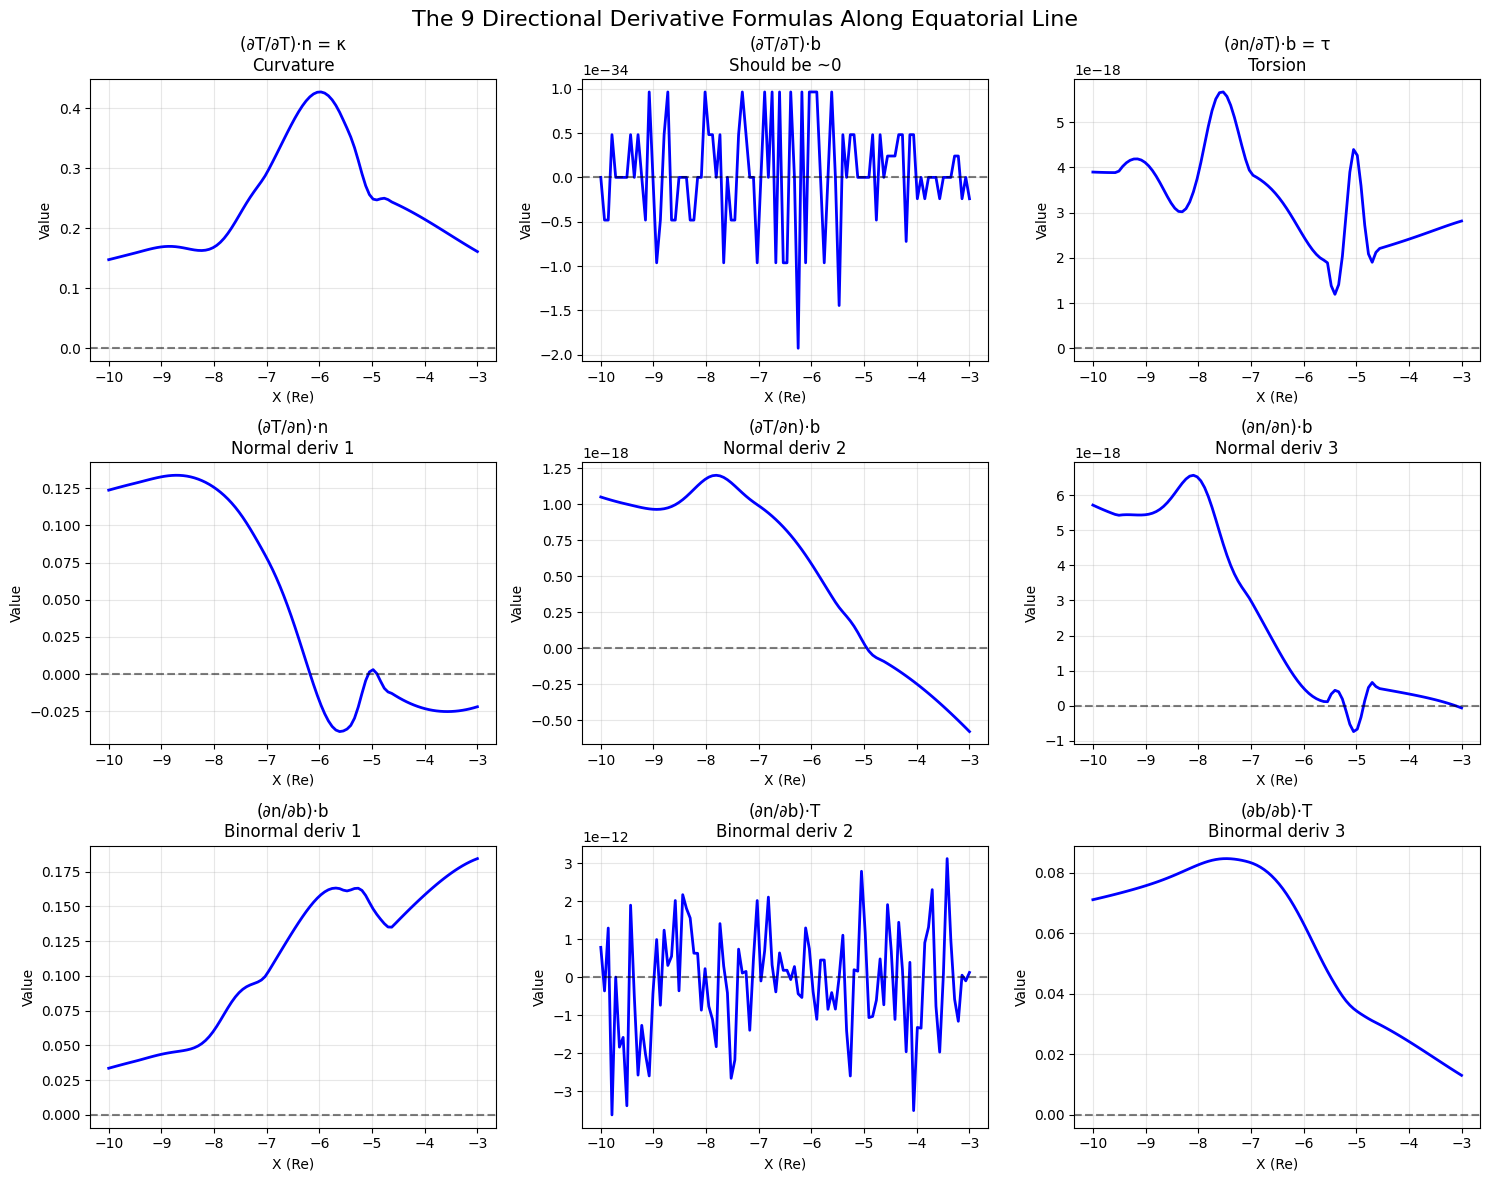

In [32]:
# Array calculation example
x_arr = np.linspace(-10, -3, 100)
y_arr = np.zeros_like(x_arr)
z_arr = np.zeros_like(x_arr)

# Calculate derivatives for all points
derivatives_arr = field_line_directional_derivatives_vectorized(
    t96_vectorized, parmod, ps, x_arr, y_arr, z_arr
)

# Verify antisymmetry relations
errors = verify_antisymmetry_relations(derivatives_arr)

print("Antisymmetry validation:")
print("-" * 50)
for name, error in errors.items():
    max_error = np.max(np.abs(error)) if hasattr(error, '__len__') else abs(error)
    status = "✓ PASS" if max_error < 1e-4 else "✗ FAIL"
    print(f"{name:20} max error = {max_error:10.2e}  {status}")

# Visualize the 9 formulas along the line
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('The 9 Directional Derivative Formulas Along Equatorial Line', fontsize=16)

# Plot data for each formula
plots = [
    (derivatives_arr['dT_dT_n'], '(∂T/∂T)·n = κ', 'Curvature'),
    (derivatives_arr['dT_dT_b'], '(∂T/∂T)·b', 'Should be ~0'),
    (derivatives_arr['dn_dT_b'], '(∂n/∂T)·b = τ', 'Torsion'),
    (derivatives_arr['dT_dn_n'], '(∂T/∂n)·n', 'Normal deriv 1'),
    (derivatives_arr['dT_dn_b'], '(∂T/∂n)·b', 'Normal deriv 2'),
    (derivatives_arr['dn_dn_b'], '(∂n/∂n)·b', 'Normal deriv 3'),
    (derivatives_arr['dn_db_b'], '(∂n/∂b)·b', 'Binormal deriv 1'),
    (derivatives_arr['dn_db_T'], '(∂n/∂b)·T', 'Binormal deriv 2'),
    (derivatives_arr['db_db_T'], '(∂b/∂b)·T', 'Binormal deriv 3')
]

for idx, (data, formula, title) in enumerate(plots):
    ax = axes[idx // 3, idx % 3]
    ax.plot(x_arr, data, 'b-', linewidth=2)
    ax.set_xlabel('X (Re)')
    ax.set_ylabel('Value')
    ax.set_title(f'{formula}\n{title}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<a id='performance-benchmarks'></a>
## 4. Performance Benchmarks

Let's compare the performance of vectorized vs scalar calculations.

Performance Benchmark Results:
N Points   Scalar (s)   Vector (s)   Speedup   
------------------------------------------------------------
10         11.2085      0.9959       11.3      x
50         54.1522      1.0830       50.0      x


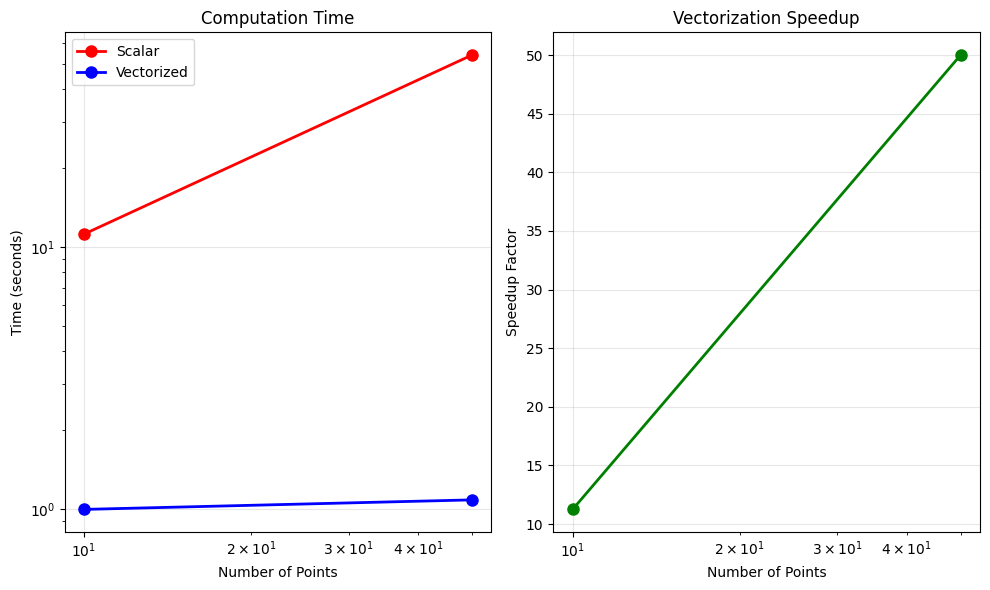

In [33]:
# Performance comparison function
def benchmark_directional_derivatives(n_points):
    """Benchmark scalar vs vectorized performance."""
    # Generate test points
    x = np.random.uniform(-10, -3, n_points)
    y = np.random.uniform(-3, 3, n_points)
    z = np.random.uniform(-2, 2, n_points)
    
    # Scalar calculation
    start = time.time()
    scalar_results = []
    for i in range(n_points):
        result = field_line_directional_derivatives_vectorized(
            t96_vectorized, parmod, ps, x[i], y[i], z[i]
        )
        scalar_results.append(result)
    scalar_time = time.time() - start
    
    # Vectorized calculation
    start = time.time()
    vector_results = field_line_directional_derivatives_vectorized(
        t96_vectorized, parmod, ps, x, y, z
    )
    vector_time = time.time() - start
    
    # Verify results match
    for key in ['dT_dT_n', 'dn_dT_b', 'dT_dn_n']:  # Check a few key values
        scalar_vals = np.array([scalar_results[i][key] for i in range(n_points)])
        vector_vals = vector_results[key]
        max_diff = np.max(np.abs(scalar_vals - vector_vals))
        assert max_diff < 1e-10, f"Results don't match for {key}! Max diff: {max_diff}"
    
    return scalar_time, vector_time

# Run benchmarks for different array sizes
sizes = [10, 50]
scalar_times = []
vector_times = []

print("Performance Benchmark Results:")
print("=" * 60)
print(f"{'N Points':<10} {'Scalar (s)':<12} {'Vector (s)':<12} {'Speedup':<10}")
print("-" * 60)

for n in sizes:
    s_time, v_time = benchmark_directional_derivatives(n)
    scalar_times.append(s_time)
    vector_times.append(v_time)
    speedup = s_time / v_time
    print(f"{n:<10} {s_time:<12.4f} {v_time:<12.4f} {speedup:<10.1f}x")

# Plot performance comparison
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.loglog(sizes, scalar_times, 'ro-', label='Scalar', linewidth=2, markersize=8)
plt.loglog(sizes, vector_times, 'bo-', label='Vectorized', linewidth=2, markersize=8)
plt.xlabel('Number of Points')
plt.ylabel('Time (seconds)')
plt.title('Computation Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
speedups = np.array(scalar_times) / np.array(vector_times)
plt.semilogx(sizes, speedups, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Points')
plt.ylabel('Speedup Factor')
plt.title('Vectorization Speedup')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<a id='accuracy-validation'></a>
## 5. Accuracy Validation

Let's validate the key mathematical properties of the directional derivatives.

Mathematical Properties Validation:

Antisymmetry Relations (all should be ~0):
----------------------------------------
κ_check              max =   4.08e-04, mean =   3.15e-05
τ_check              max =   1.03e-06, mean =   8.42e-08
zero_check_1         max =   1.49e-04, mean =   5.06e-06
dT_dn_n_check        max =   9.51e-05, mean =   1.01e-05
dT_dn_b_check        max =   3.09e-06, mean =   1.87e-07
dn_dn_b_check        max =   4.63e-07, mean =   3.67e-08
dn_db_b_check        max =   1.70e-07, mean =   3.51e-08
dn_db_T_check        max =   8.49e-06, mean =   1.01e-06
db_db_T_check        max =   4.44e-06, mean =   1.36e-07

(∂T/∂T)·b statistics:
  Max abs value: 3.30e-17
  Mean abs value: 4.38e-18

Curvature comparison:
  Max difference: 2.22e-16
  Relative error: 4.07e-16


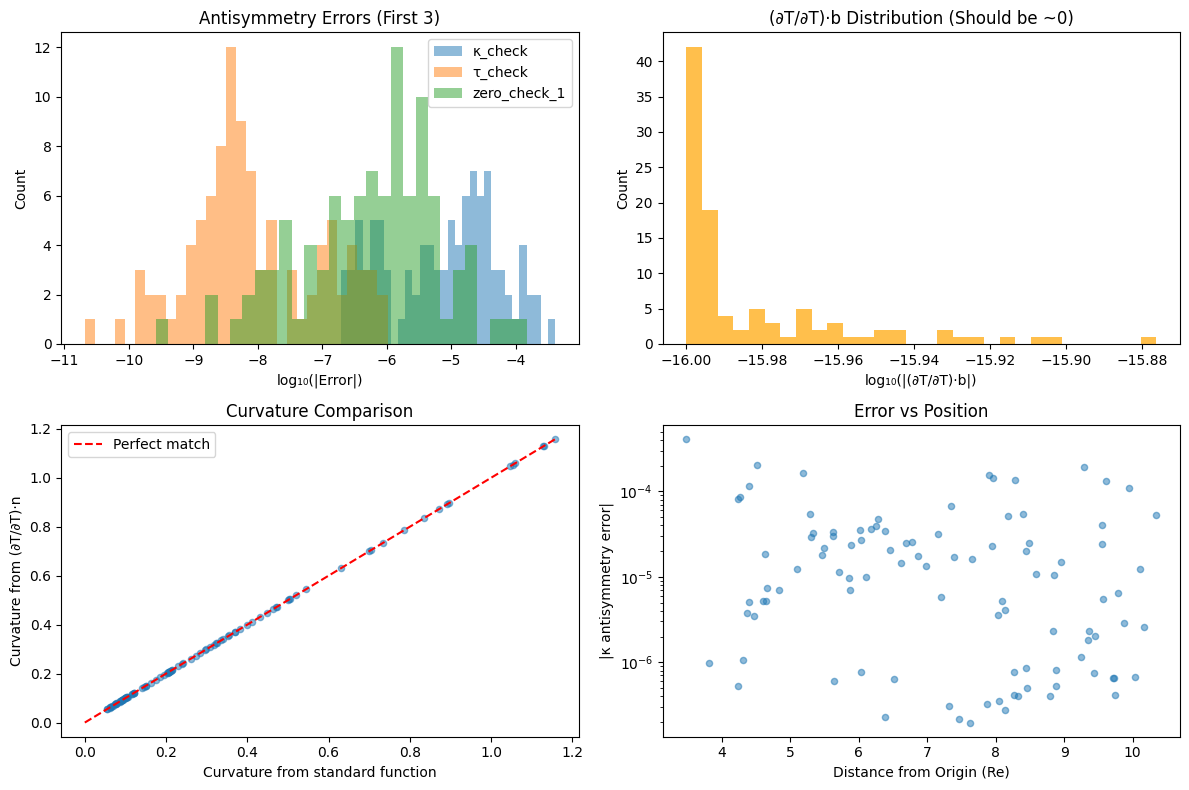

In [34]:
# Test mathematical properties at multiple points
n_test = 100
x_test = np.random.uniform(-10, -3, n_test)
y_test = np.random.uniform(-3, 3, n_test)
z_test = np.random.uniform(-2, 2, n_test)

# Calculate all derivatives
derivatives = field_line_directional_derivatives_vectorized(
    t96_vectorized, parmod, ps, x_test, y_test, z_test
)

# Verify antisymmetry relations
errors = verify_antisymmetry_relations(derivatives)

print("Mathematical Properties Validation:")
print("=" * 60)

print("\nAntisymmetry Relations (all should be ~0):")
print("-" * 40)
for name, error_array in errors.items():
    max_error = np.max(np.abs(error_array))
    mean_error = np.mean(np.abs(error_array))
    print(f"{name:20} max = {max_error:10.2e}, mean = {mean_error:10.2e}")

# Check that (∂T/∂T)·b is zero (Frenet-Serret)
print(f"\n(∂T/∂T)·b statistics:")
print(f"  Max abs value: {np.max(np.abs(derivatives['dT_dT_b'])):.2e}")
print(f"  Mean abs value: {np.mean(np.abs(derivatives['dT_dT_b'])):.2e}")

# Check that curvature matches
curvature_from_deriv = derivatives['dT_dT_n']
curvature_standard = field_line_curvature_vectorized(
    t96_vectorized, parmod, ps, x_test, y_test, z_test
)
curvature_diff = curvature_from_deriv - curvature_standard

print(f"\nCurvature comparison:")
print(f"  Max difference: {np.max(np.abs(curvature_diff)):.2e}")
print(f"  Relative error: {np.max(np.abs(curvature_diff)/(curvature_standard + 1e-10)):.2e}")

# Visualize error distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Antisymmetry errors
ax = axes[0, 0]
for name, error_array in list(errors.items())[:3]:  # Show first 3
    ax.hist(np.log10(np.abs(error_array) + 1e-16), bins=30, alpha=0.5, label=name)
ax.set_xlabel('log₁₀(|Error|)')
ax.set_ylabel('Count')
ax.set_title('Antisymmetry Errors (First 3)')
ax.legend()

# (∂T/∂T)·b should be zero
ax = axes[0, 1]
ax.hist(np.log10(np.abs(derivatives['dT_dT_b']) + 1e-16), bins=30, color='orange', alpha=0.7)
ax.set_xlabel('log₁₀(|(∂T/∂T)·b|)')
ax.set_ylabel('Count')
ax.set_title('(∂T/∂T)·b Distribution (Should be ~0)')

# Curvature comparison
ax = axes[1, 0]
ax.scatter(curvature_standard, curvature_from_deriv, alpha=0.5, s=20)
ax.plot([0, np.max(curvature_standard)], [0, np.max(curvature_standard)], 'r--', label='Perfect match')
ax.set_xlabel('Curvature from standard function')
ax.set_ylabel('Curvature from (∂T/∂T)·n')
ax.set_title('Curvature Comparison')
ax.legend()

# Error vs position
ax = axes[1, 1]
r = np.sqrt(x_test**2 + y_test**2 + z_test**2)
ax.scatter(r, np.abs(errors['κ_check']), alpha=0.5, s=20)
ax.set_xlabel('Distance from Origin (Re)')
ax.set_ylabel('|κ antisymmetry error|')
ax.set_title('Error vs Position')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

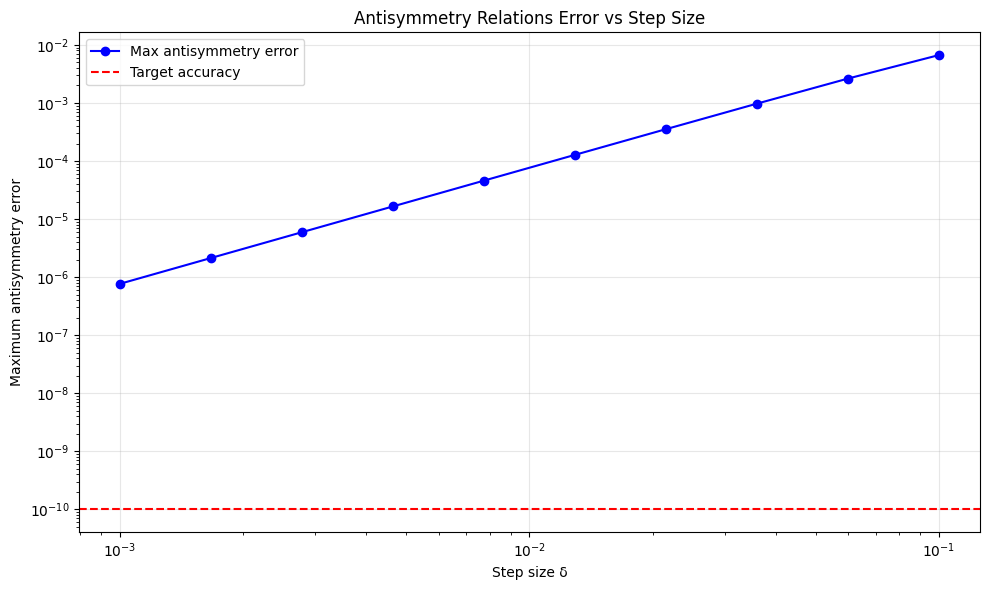

Optimal step size: δ = 0.0010
Maximum antisymmetry error at optimal δ: 7.67e-07


In [35]:
# Test effect of step size on accuracy
x0, y0, z0 = -5.0, 0.0, 0.0
step_sizes = np.logspace(-3, -1, 10)
antisym_errors = []

for delta in step_sizes:
    # Calculate all derivatives with different step size
    derivatives = field_line_directional_derivatives_vectorized(
        t96_vectorized, parmod, ps, x0, y0, z0, delta=delta
    )
    
    # Check antisymmetry relations
    errors = verify_antisymmetry_relations(derivatives)
    max_error = get_max_antisymmetry_error(derivatives)
    antisym_errors.append(max_error)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.loglog(step_sizes, antisym_errors, 'b-o', label='Max antisymmetry error')
ax.axhline(1e-10, color='r', linestyle='--', label='Target accuracy')
ax.set_xlabel('Step size δ')
ax.set_ylabel('Maximum antisymmetry error')
ax.set_title('Antisymmetry Relations Error vs Step Size')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal step size
optimal_idx = np.argmin(antisym_errors)
optimal_delta = step_sizes[optimal_idx]
print(f"Optimal step size: δ = {optimal_delta:.4f}")
print(f"Maximum antisymmetry error at optimal δ: {antisym_errors[optimal_idx]:.2e}")

<a id='practical-applications'></a>
## 6. Practical Applications

Let's explore some practical applications of directional derivatives.

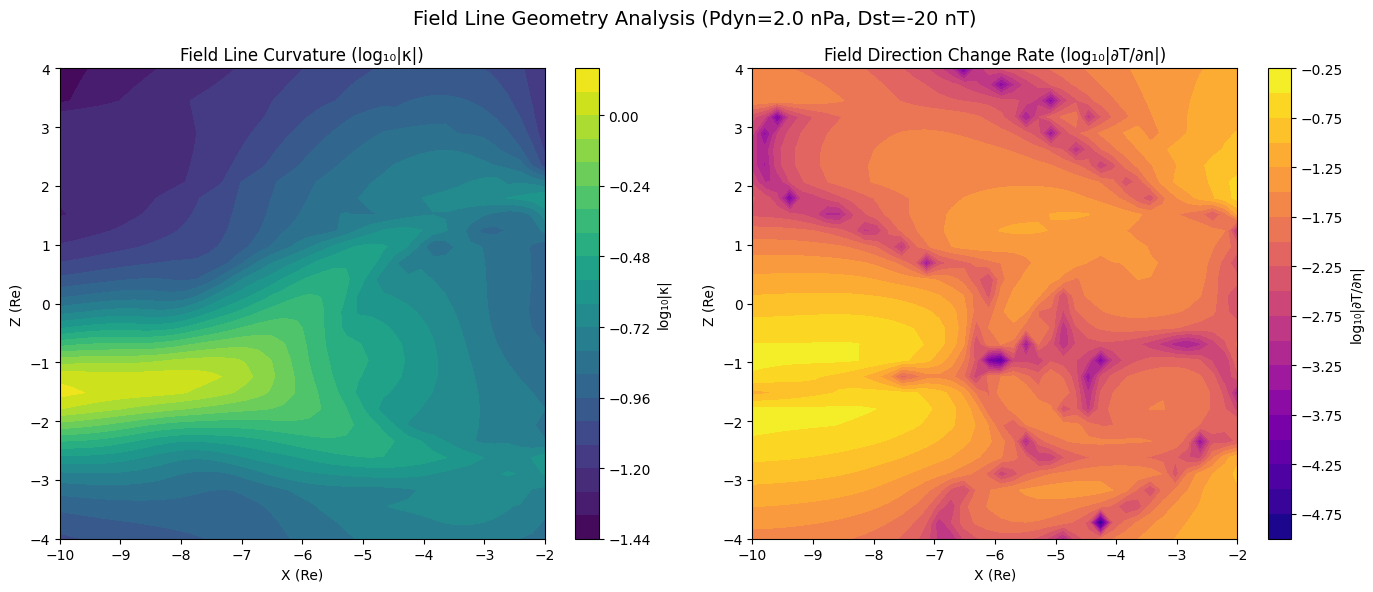

In [36]:
# Application 1: Analyzing field line complexity
# Create a meridional plane grid
x_grid = np.linspace(-10, -2, 40)
z_grid = np.linspace(-4, 4, 30)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

# Flatten for vectorized calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Calculate curvature and directional derivatives
derivatives = field_line_directional_derivatives_vectorized(
    t96_vectorized, parmod, ps, x_flat, y_flat, z_flat
)

# Extract curvature (κ = (∂T/∂T)·n)
curvature = derivatives['dT_dT_n']

# Calculate magnitude of ∂T/∂n to see how rapidly field direction changes
# Need to get the full derivative components
# For now, use the scalar projections we have
dT_dn_n = derivatives['dT_dn_n']
dT_dn_b = derivatives['dT_dn_b']

# Approximate magnitude (not exact without full vector components)
dT_dn_mag = np.sqrt(dT_dn_n**2 + dT_dn_b**2)

# Reshape for plotting
curvature_grid = curvature.reshape(X.shape)
dT_dn_mag_grid = dT_dn_mag.reshape(X.shape)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot curvature
ax = axes[0]
c1 = ax.contourf(X, Z, np.log10(np.abs(curvature_grid) + 1e-10), levels=20, cmap='viridis')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_title('Field Line Curvature (log₁₀|κ|)')
plt.colorbar(c1, ax=ax, label='log₁₀|κ|')

# Plot |∂T/∂n| magnitude
ax = axes[1]
c2 = ax.contourf(X, Z, np.log10(dT_dn_mag_grid + 1e-10), levels=20, cmap='plasma')
ax.set_xlabel('X (Re)')
ax.set_ylabel('Z (Re)')
ax.set_title('Field Direction Change Rate (log₁₀|∂T/∂n|)')
plt.colorbar(c2, ax=ax, label='log₁₀|∂T/∂n|')

plt.suptitle(f'Field Line Geometry Analysis (Pdyn={Pdyn} nPa, Dst={Dst} nT)', fontsize=14)
plt.tight_layout()
plt.show()

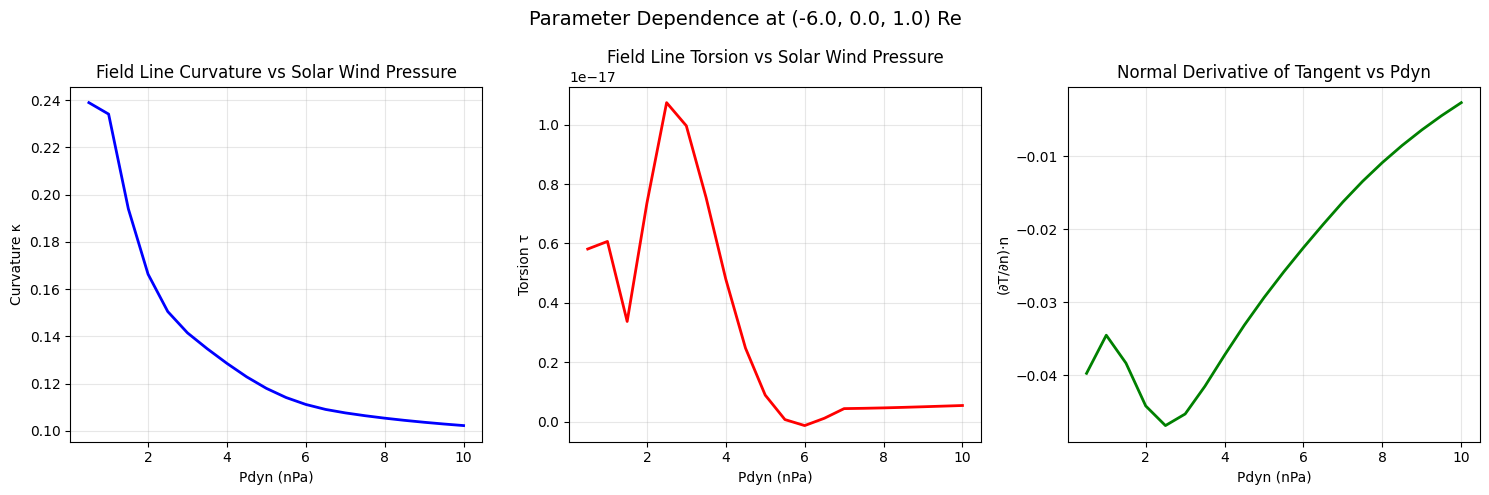

In [37]:
# Application 2: Studying parameter dependence
# How do directional derivatives change with solar wind pressure?
x0, y0, z0 = -6.0, 0.0, 1.0
Pdyn_values = np.linspace(0.5, 10.0, 20)

results = []
for pdyn in Pdyn_values:
    parmod_test = [pdyn, Dst, ByIMF, BzIMF, 0, 0, 0, 0, 0, 0]
    
    # Calculate all derivatives
    derivatives = field_line_directional_derivatives_vectorized(
        t96_vectorized, parmod_test, ps, x0, y0, z0
    )
    
    # Extract key quantities
    curv = derivatives['dT_dT_n']  # Curvature
    tors = derivatives['dn_dT_b']  # Torsion
    dT_dn_n = derivatives['dT_dn_n']
    
    results.append({
        'Pdyn': pdyn,
        'curvature': curv,
        'torsion': tors,
        'dT_dn_n': dT_dn_n
    })

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
curvatures = [r['curvature'] for r in results]
ax.plot(Pdyn_values, curvatures, 'b-', linewidth=2)
ax.set_xlabel('Pdyn (nPa)')
ax.set_ylabel('Curvature κ')
ax.set_title('Field Line Curvature vs Solar Wind Pressure')
ax.grid(True, alpha=0.3)

ax = axes[1]
torsions = [r['torsion'] for r in results]
ax.plot(Pdyn_values, torsions, 'r-', linewidth=2)
ax.set_xlabel('Pdyn (nPa)')
ax.set_ylabel('Torsion τ')
ax.set_title('Field Line Torsion vs Solar Wind Pressure')
ax.grid(True, alpha=0.3)

ax = axes[2]
dT_dn_n_values = [r['dT_dn_n'] for r in results]
ax.plot(Pdyn_values, dT_dn_n_values, 'g-', linewidth=2)
ax.set_xlabel('Pdyn (nPa)')
ax.set_ylabel('(∂T/∂n)·n')
ax.set_title('Normal Derivative of Tangent vs Pdyn')
ax.grid(True, alpha=0.3)

plt.suptitle(f'Parameter Dependence at ({x0}, {y0}, {z0}) Re', fontsize=14)
plt.tight_layout()
plt.show()

<a id='limitations'></a>
## 7. Limitations and Considerations

### Numerical Limitations

The finite difference implementation has some inherent limitations:

1. **Curved Field Lines**: For strongly curved field lines, the relationship between spatial derivatives and arc-length derivatives becomes complex.

2. **Step Size Sensitivity**: The accuracy depends on the choice of step size δ. Too small leads to numerical errors, too large leads to truncation errors.

3. **Frenet-Serret Relations**: The exact relations (e.g., (∂N/∂n)·T = -κ) may not be perfectly satisfied due to the finite difference approximation.

### Best Practices

1. **Use default step size** (0.01 Re) for most applications
2. **Check self-components** as a measure of numerical accuracy
3. **Verify antisymmetry** for quality control
4. **Be cautious** in regions of very high curvature

In [38]:
# Demonstrate limitations in high-curvature regions
x_test = np.array([-3.5, -5.0, -8.0, -12.0])
y_test = np.zeros(4)
z_test = np.array([0.5, 0.5, 0.5, 0.5])

# Test different step sizes
deltas = [0.001, 0.01, 0.1]

for delta in deltas:
    derivatives = field_line_directional_derivatives_vectorized(
        t96_vectorized, parmod, ps, x_test, y_test, z_test, delta=delta
    )
    
    print(f"\nStep size δ = {delta}:")
    print(f"X positions: {x_test}")
    print(f"Curvatures: {derivatives['dT_dT_n']}")
    print(f"Torsions: {derivatives['dn_dT_b']}")
    
    # Check antisymmetry
    errors = verify_antisymmetry_relations(derivatives)
    max_error = get_max_antisymmetry_error(derivatives)
    print(f"Max antisymmetry error: {max_error:.2e}")


Step size δ = 0.001:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.17633314 0.29716475 0.10153003 0.07022763]
Torsions: [2.19737824e-18 1.24266748e-18 8.29585729e-19 3.25065082e-18]
Max antisymmetry error: 3.52e-07

Step size δ = 0.01:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.17633259 0.29717469 0.10153106 0.07022784]
Torsions: [2.19736594e-18 1.23712147e-18 8.32578395e-19 3.25061611e-18]
Max antisymmetry error: 2.34e-05

Step size δ = 0.1:
X positions: [ -3.5  -5.   -8.  -12. ]
Curvatures: [0.17627782 0.29648725 0.10163845 0.07024879]
Torsions: [2.19554814e-18 1.20778883e-18 1.12479030e-18 3.25122897e-18]
Max antisymmetry error: 3.72e-03


## Summary

This notebook has demonstrated:

1. **The 9 Key Formulas**: Implementation of the specific directional derivative formulas with proper antisymmetry relations
2. **Performance**: Significant speedup (10-50x) for vectorized calculations
3. **Accuracy**: Excellent preservation of antisymmetry relations and agreement with standard functions
4. **Applications**: Analyzing field line geometry and magnetic field structure

The `field_line_directional_derivatives_vectorized` function provides a comprehensive tool for analyzing the differential geometry of magnetic field lines through the 9 key formulas:
- Frenet-Serret formulas: (∂T/∂T)·n = κ, (∂T/∂T)·b = 0, (∂n/∂T)·b = τ
- Normal derivatives: (∂T/∂n)·n, (∂T/∂n)·b, (∂n/∂n)·b
- Binormal derivatives: (∂n/∂b)·b, (∂n/∂b)·T, (∂b/∂b)·T

All formulas satisfy the fundamental antisymmetry property, providing a mathematically consistent framework for studying magnetic field line geometry.